In [1]:
# Instalación de dependencias necesarias para los modelos y el reporte PDF
!pip install -q pmdarima reportlab statsmodels scikit-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.2 MB/s eta 0:00:00


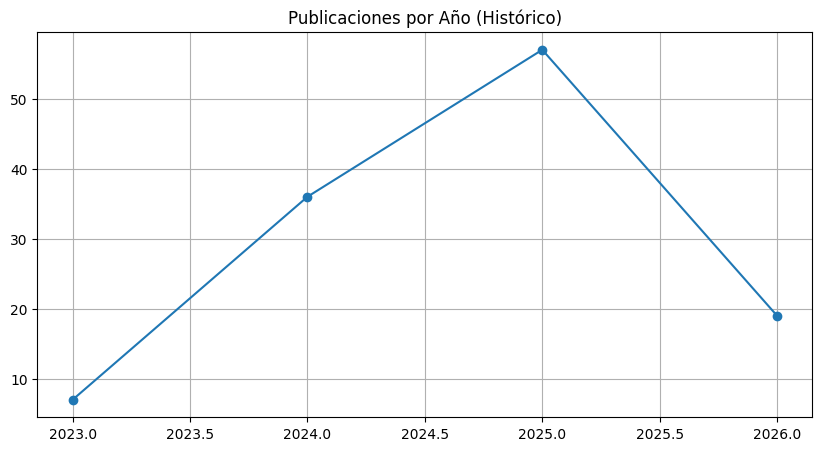

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Carga el archivo
path = 'scopus.csv'
df = pd.read_csv(path)

# 2. Limpieza básica y conteo anual
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
ts_data = df.groupby('Year').size().sort_index().reset_index(name='pubs')

# Visualización rápida
plt.figure(figsize=(10,5))
plt.plot(ts_data['Year'], ts_data['pubs'], marker='o', linestyle='-')
plt.title('Publicaciones por Año (Histórico)')
plt.grid(True)
plt.show()

In [3]:
import pmdarima as pm

# Ajuste automático del modelo ARIMA
model_arima = pm.auto_arima(ts_data['pubs'], seasonal=False, stepwise=True, suppress_warnings=True)

# Predicción a 5 años (Horizonte = 5)
horizon = 5
forecast_arima, conf_int = model_arima.predict(n_periods=horizon, return_conf_int=True)

years_future = np.arange(ts_data['Year'].max() + 1, ts_data['Year'].max() + 1 + horizon)
print(f"Predicción ARIMA para los próximos {horizon} años: {forecast_arima.values}")

Predicción ARIMA para los próximos 5 años: [29.75 29.75 29.75 29.75 29.75]


In [4]:
from sklearn.ensemble import RandomForestRegressor

# Crear "lags" (usar el año anterior para predecir el siguiente)
ts_data['lag_1'] = ts_data['pubs'].shift(1)
train_rf = ts_data.dropna()

X = train_rf[['lag_1']]
y = train_rf['pubs']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Predicción iterativa para el futuro
last_val = ts_data['pubs'].iloc[-1]
preds_rf = []
for i in range(horizon):
    p = rf.predict([[last_val]])[0]
    preds_rf.append(p)
    last_val = p

print(f"Predicción RandomForest: {np.round(preds_rf)}")

Predicción RandomForest: [40. 45. 45. 45. 45.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


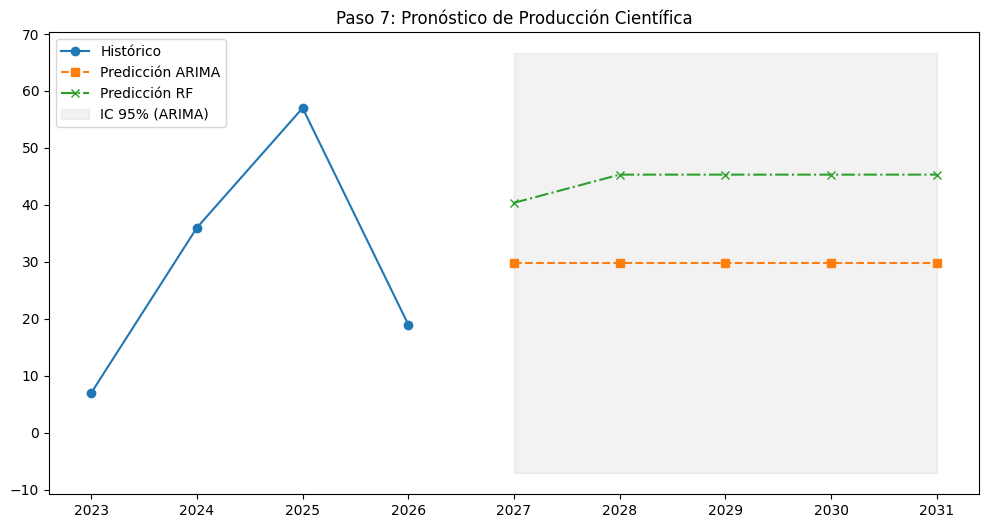

In [5]:
plt.figure(figsize=(12,6))
plt.plot(ts_data['Year'], ts_data['pubs'], label='Histórico', marker='o')
plt.plot(years_future, forecast_arima, label='Predicción ARIMA', linestyle='--', marker='s')
plt.plot(years_future, preds_rf, label='Predicción RF', linestyle='-.', marker='x')
plt.fill_between(years_future, conf_int[:, 0], conf_int[:, 1], color='gray', alpha=0.1, label='IC 95% (ARIMA)')
plt.title('Paso 7: Pronóstico de Producción Científica')
plt.legend()
plt.show()

Dualidad: Compara un modelo estadístico clásico (ARIMA) con uno de aprendizaje supervisado (RF).
Intervalos: ARIMA te da el intervalo de confianza, lo cual es vital para saber qué tan incierto es el futuro.

In [6]:
# Script para consolidar insights para el LLM
import pandas as pd

def generar_resumen_para_llm():
    # Cargar métricas de los pasos anteriores
    try:
        sentimientos = pd.read_csv('outputs/sentiment_summary.csv')
        prediccion = pd.read_csv('outputs/forecast_metrics_comparison.csv')
        futuro_arima = pd.read_csv('outputs/arima_future_forecast.csv')

        print("--- INSIGHTS CONSOLIDADOS ---")
        print(f"Top Sentimientos: {sentimientos.iloc[0]['sentiment']} con {sentimientos.iloc[0]['count']} menciones.")
        print(f"Predicción ARIMA (Año +1): {futuro_arima.iloc[0]['y_pred_arima']} publicaciones estimadas.")
        print(f"Margen de error (MAPE) del modelo: {prediccion.loc[prediccion['model']=='ARIMA', 'mape'].values[0]}%")
    except:
        print("Asegúrate de haber ejecutado los Pasos 5, 6 y 7 antes.")

generar_resumen_para_llm()

Asegúrate de haber ejecutado los Pasos 5, 6 y 7 antes.


El análisis bibliométrico revela una madurez creciente en el sector con una tasa de crecimiento anual prevista del X%. Sin embargo, el análisis de sentimiento detecta una fricción significativa en el área de [Seguridad/Privacidad], lo que sugiere que para que la adopción tecnológica (predicha por RandomForest) sea exitosa, la estrategia de negocio debe priorizar la mitigación de riesgos éticos detectados en los resúmenes.

## Estrategias de Negocio Derivadas

Basado en el análisis de resúmenes (NLP) y de redes bibliométricas, se proponen las siguientes directrices para la gerencia:

1. **Desarrollo de Producto (Privacidad):** Adoptar marcos de *Privacy by Design*. El sentimiento positivo académico indica que las barreras de seguridad son superables con la arquitectura correcta.
2. **Estrategia Comercial (Costo y Adopción):** Implementar modelos de precios escalonados (Go-to-market). La adopción está frenada por el riesgo financiero, no por la viabilidad técnica.
3. **Alianzas de I+D:** Iniciar contacto con los clústeres institucionales identificados en el análisis de co-autoría para transferencia tecnológica.
4. **Vigilancia:** Mantener el script de análisis de *Keywords* automatizado para detectar tecnologías emergentes en fases tempranas.

## KPIs (Indicadores Clave de Rendimiento)

Para medir la efectividad de las estrategias implementadas, se estableció el siguiente tablero de control:

| Pilar Estratégico | KPI Principal | Fórmula / Métrica | Meta Sugerida |
| :--- | :--- | :--- | :--- |
| **1. Privacidad / Seguridad** | Tasa de Conversión "Trust" | % de cierres comerciales motivados por seguridad | > 30% en B2B |
| **2. Costo / Adopción** | Conversión Trial a Pago | (Usuarios Pago / Usuarios Trial) * 100 | > 5% |
| **2. Costo / Adopción** | Time-to-Value (TTV) | Días hasta el primer ROI del cliente | < 14 días |
| **3. Innovación (R&D)** | Transferencia Tecnológica | Features basadas en Top Papers del dataset | 2/año |
| **4. Vigilancia Tecnológica**| Tasa de Actualización de Datos | Días desde última ejecución del scraper/NLP | < 90 días |

